In [2]:
import tkinter as tk
from tkinter import filedialog
import openpyxl
import os
import re
from typing import Dict, Any, List, Tuple, Optional
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind

In [3]:
def analyze_excel_file():
    """
    Prompts the user to select an Excel file, reads the file, and returns
    its file path and a list of all worksheet names.

    Requires:
        - The 'openpyxl' library (install with: pip install openpyxl)
        - tkinter (usually included with Python)

    Returns:
        tuple: (file_path: str or None, sheet_names: list[str] or None)
    """
    # Initialize tkinter root and immediately hide the main window,
    # as we only need the file dialog.
    root = tk.Tk()
    root.withdraw()
    
    print("--- Opening file selection dialog. Please choose an Excel (.xlsx) file. ---")

    # Prompt user for file selection
    file_path = filedialog.askopenfilename(
        title="Select an Excel Workbook (.xlsx)",
        defaultextension=".xlsx",
        filetypes=[("Excel files", "*.xlsx"), ("All files", "*.*")]
    )

    # Clean up the tkinter root
    root.destroy()
    
    # Check if a file was selected (i.e., the dialog was not canceled)
    if not file_path:
        print("\nSelection canceled. No file was chosen.")
        return None, None
    
    try:
        # Load the workbook from the selected path
        workbook = openpyxl.load_workbook(file_path)
        
        # Retrieve the list of all worksheet names
        sheet_names = workbook.sheetnames
        
        print(f"\nSuccessfully analyzed: {os.path.basename(file_path)}")
        print(f"Found {len(sheet_names)} worksheets.")

        return file_path, sheet_names
        
    except FileNotFoundError:
        print(f"\nError: File not found at path: {file_path}")
        return None, None
    except Exception as e:
        print(f"\nAn error occurred while processing the Excel file: {e}")
        return None, None

# --- Global Environment Variable Assignment and Printing ---

print("Starting Excel Analyzer function...")

# 1. Call the function, capturing the two return values
excel_file_path, worksheet_names = analyze_excel_file()

print("\n--- Results in Global Environment ---")

# 2. Check if the analysis was successful before printing
if excel_file_path and worksheet_names:
    
    # 3. Print the path (stored in excel_file_path)
    print(f"Stored File Path (excel_file_path): {excel_file_path}")
    
    # 4. Print the list of worksheet names (stored in worksheet_names)
    print("Stored List of Worksheet Names (worksheet_names):")
    for name in worksheet_names:
        print(f"- {name}")
        
    print("\nAnalysis complete.")
else:
    print("No data was returned from the function due to cancellation or an error.")


Starting Excel Analyzer function...
--- Opening file selection dialog. Please choose an Excel (.xlsx) file. ---

Successfully analyzed: EIS gldlpdoct22.xlsx
Found 51 worksheets.

--- Results in Global Environment ---
Stored File Path (excel_file_path): C:/Users/austi/OneDrive - UC San Diego/Documents/EIS gldlpdoct22.xlsx
Stored List of Worksheet Names (worksheet_names):
- 80%_D2_T2_M3
- 80%_D2_T2_M2
- 80%_D2_T2_M1
- 80%_D2_T1_M3
- 80%_D2_T1_M2
- 80%_D2_T1_M1
- 65%_D2_T3_M3
- 65%_D2_T2_M2.
- 65%_D2_T2_M1.
- 65%_D2_T1_M3
- 65%_D2_T1_M2
- 65%_D2_T1_M1
- 50%_D2_T2_M3.
- 50%_D2_T2_M2.
- 50%_D2_T2_M1.
- 50%_D2_T1_M3
- 50%_D2_T1_M2
- 50%_D2_T1_M1
- 10_D2_M3
- 10_D2_M2
- 10_D2_M1
- Sheet33
- Sheet32
- badTenOhm
- open_D2_M3
- open_D2_M2
- open_D2_M1
- 80%_D1_T2_M3
- 80%_D1_T2_M2
- 80%_D1_T2_M1
- 80%_D1_T1_M3
- 80%_D1_T1_M2
- 80%_D1_T1_M1
- 65%_D1_T2_M3
- 65%_D1_T2_M2
- 65%_D1_T2_M1
- 65%_D1_T1_M3
- 65%_D1_T1_M2
- 65%_D1_T1_M1
- 50%_D1_T2_M3
- 50%_D1_T2_M2
- 50%_D1_T2_M1
- 50%_D1_T1_M3
- 50%_D1

In [4]:
def process_excel_data(file_path: str, all_sheet_names: list) -> dict:
    """
    Filters worksheets by name (handling both 3-part and 4-part names), 
    parses experimental parameters, extracts data from columns A and C, 
    and organizes it into a structured, sorted dictionary.

    Args:
        file_path (str): The path to the Excel file.
        all_sheet_names (list): A list of all sheet names in the workbook.

    Returns:
        dict: The main nested dictionary containing all processed and raw data.
    """
    if not file_path or not all_sheet_names:
        print("\n⚠️ Cannot process data: File path or sheet names list is empty.")
        return {}

    main_dictionary = {}
    
    # Define the custom sorting order (priority is from left to right)
    # T is included here for sheets that have it, but it's optional for 'open'/'10'.
    sort_priority = {
        "experiment": {"open": 0, "10": 1, "80%": 2, "65%": 3, "50%": 4},
        "day": {"D1": 0, "D2": 1},
        "T": {"T1": 0, "T2": 1},
        "M": {"M1": 0, "M2": 1, "M3": 2}
    }
    
    # Experiments that do NOT have the 'T' parameter (3-part names)
    EXP_NO_T = ["open", "10"]

    # 1. Load the workbook (data_only=True to get raw cell values)
    try:
        workbook = openpyxl.load_workbook(file_path, data_only=True)
    except Exception as e:
        print(f"\n❌ Error loading workbook for processing: {e}")
        return {}

    parsed_sheets = []

    print("\n--- Starting Data Parsing ---")
    
    # 2. Filter and Parse Sheet Names
    for sheet_name in all_sheet_names:
        if "_" not in sheet_name:
            continue
            
        # Clean the name: remove anything that is not a letter, digit, "_", or "%"
        cleaned_name = re.sub(r'[^a-zA-Z0-9_%_]', '', sheet_name)
        parts = cleaned_name.split("_")
        
        exp_params = {}
        is_valid = False
        
        # --- Handle 4-Part Names (E_D_T_M) ---
        if len(parts) == 4:
            exp_params = {
                "experiment": parts[0], "day": parts[1], "T": parts[2], "M": parts[3]
            }
            # Check if all four parts are valid and if the experiment SHOULD have T
            if exp_params["experiment"] not in EXP_NO_T and \
               all(exp_params.get(key) in sort_priority.get(key, {}) for key in ["experiment", "day", "T", "M"]):
                is_valid = True
            else:
                print(f"⚠️ Sheet '{sheet_name}' filtered (4 parts, but exp '{exp_params['experiment']}' shouldn't have T or invalid param).")
                
        # --- Handle 3-Part Names (E_D_M) ---
        elif len(parts) == 3:
            exp_params = {
                "experiment": parts[0], "day": parts[1], "M": parts[2], "T": None # Explicitly set T to None
            }
            # Check if the experiment is one that should NOT have T
            if exp_params["experiment"] in EXP_NO_T and \
               all(exp_params.get(key) in sort_priority.get(key, {}) for key in ["experiment", "day", "M"]):
                is_valid = True
            else:
                print(f"⚠️ Sheet '{sheet_name}' filtered (3 parts, but exp '{exp_params['experiment']}' is not 'open' or '10' or invalid param).")

        # --- Store valid sheets ---
        if is_valid:
            parsed_sheets.append({
                "sheet_name": sheet_name,
                "params": exp_params
            })
        elif not is_valid and "_" in sheet_name:
             print(f"⚠️ Sheet '{sheet_name}' filtered (Name format or parameters invalid).")
        
    # 3. Sort the Parsed Sheets
    def sort_key(item):
        params = item['params']
        # For 'T', if the value is None (3-part sheet), it gets -1 priority, 
        # ensuring it sorts before T1 (priority 0) and T2 (priority 1).
        t_priority = sort_priority["T"].get(params.get("T"), -1) 
        
        return (
            sort_priority["experiment"].get(params["experiment"], 99), 
            sort_priority["day"].get(params["day"], 99),
            t_priority,
            sort_priority["M"].get(params["M"], 99)
        )

    parsed_sheets.sort(key=sort_key)
    print(f"✅ Successfully filtered and sorted {len(parsed_sheets)} sheets.")
    
    
    # 4. Extract Raw and Filtered Data
    for i, item in enumerate(parsed_sheets):
        sheet_name = item['sheet_name']
        params = item['params']
        
        dict_key = f"experiment {i + 1}"
        worksheet = workbook[sheet_name]
        
        freq_raw = []
        z_raw = []
        freq_filtered = []
        z_filtered = []
        
        # Iterate over all rows (starting from row 2 to skip headers)
        for row in worksheet.iter_rows(min_row=2):
            try:
                # Column A (Frequency(Hz)) is at index 0 
                # Column C (Z) is at at index 2
                frequency = float(row[0].value) if row[0].value is not None else None
                z_value = row[2].value if row[2].value is not None else None 
                
                if frequency is not None:
                    freq_raw.append(frequency)
                    z_raw.append(z_value)
                    
                    if 3000 <= frequency <= 7000:
                        freq_filtered.append(frequency)
                        z_filtered.append(z_value)
                        
            except (ValueError, TypeError):
                continue

        # Build the dictionary entry
        main_dictionary[dict_key] = {
            **params, # Embed the experiment, day, T (which might be None), M
            "Freq": freq_raw,
            "Z": z_raw,
            "Freq_3_7": freq_filtered,
            "Z_3_7": z_filtered
        }
        
    print("✨ Data processing complete. Dictionary created.")
    return main_dictionary


if excel_file_path and worksheet_names:
    # Use variable intialze to the output dictionary
    main_data_dictionary = process_excel_data(excel_file_path, worksheet_names)
else:
    main_data_dictionary = {}
    print("\nProcessing skipped because the file selection was canceled or failed.")

if main_data_dictionary:
    print("\n==============================================")
    print("📊 FINAL PROCESSED DATA DICTIONARY (main_data_dictionary)")
    print("==============================================")
    
    # Print the structure for the first few items
    count = 0
    for key, data in main_data_dictionary.items():
        if count < 5:
            print(f"\n--- {key} ---")
            print(f"  Experiment: {data['experiment']}, Day: {data['day']}, T: {data['T']}, M: {data['M']}")
            print(f"  Raw Freq Count: {len(data['Freq'])}")
            print(f"  Filtered Freq (3-7k Hz) Count: {len(data['Freq_3_7'])}")
            print(f"  Example Raw Freq/Z: {data['Freq'][:3]} / {data['Z'][:3]}")
            
        count += 1
        
    if count > 5:
        print(f"\n... (Showing only first 5 entries. Total entries: {len(main_data_dictionary)}) ...\n")
    elif count == 0:
        print("\n❌ The final dictionary is empty. Check sheet names and file contents.")

    print("Data Extracted.")


--- Starting Data Parsing ---
⚠️ Sheet '65%_D2_T3_M3' filtered (4 parts, but exp '65%' shouldn't have T or invalid param).
⚠️ Sheet '65%_D2_T3_M3' filtered (Name format or parameters invalid).
✅ Successfully filtered and sorted 47 sheets.
✨ Data processing complete. Dictionary created.

📊 FINAL PROCESSED DATA DICTIONARY (main_data_dictionary)

--- experiment 1 ---
  Experiment: open, Day: D1, T: None, M: M1
  Raw Freq Count: 201
  Filtered Freq (3-7k Hz) Count: 116
  Example Raw Freq/Z: [100.0, 134.5, 169.0] / [117859000.0, 87159800.0, 45314300.0]

--- experiment 2 ---
  Experiment: open, Day: D1, T: None, M: M2
  Raw Freq Count: 201
  Filtered Freq (3-7k Hz) Count: 116
  Example Raw Freq/Z: [100.0, 134.5, 169.0] / [95957700.0, 98096800.0, 121378000.0]

--- experiment 3 ---
  Experiment: open, Day: D1, T: None, M: M3
  Raw Freq Count: 201
  Filtered Freq (3-7k Hz) Count: 116
  Example Raw Freq/Z: [100.0, 134.5, 169.0] / [116460000.0, 74253500.0, 205201000.0]

--- experiment 4 ---
  Ex

In [5]:
def create_summary_excel(main_data_dictionary: Dict[str, Any]) -> str:
    """
    Takes the structured experiment dictionary, calculates the average Z value 
    for the 3k-7k Hz range (Z_3_7), and exports the summary to a new Excel file.

    The new file is named "aw_D_EIS_analysis.xlsx" and is placed in the 
    current working directory.

    Args:
        main_data_dictionary (Dict[str, Any]): The nested dictionary 
            containing processed experimental data.

    Returns:
        str: The full path to the newly created Excel file.
    """
    if not main_data_dictionary:
        print("⚠️ Input dictionary is empty. Cannot create summary file.")
        return ""

    # Define the output file path in the current working directory
    file_name = "aw_D_EIS_analysis.xlsx"
    # Using os.getcwd() ensures the file is created in the directory where the script is run
    output_path = os.path.join(os.getcwd(), file_name)

    # 1. Setup Workbook and Worksheet
    workbook = openpyxl.Workbook()
    sheet = workbook.active
    sheet.title = "Z_Summary"

    # Define headers
    headers = ["experiment", "day", "T", "M", "Z_avg"]
    sheet.append(headers)

    # 2. Process Data and Write Rows
    for data in main_data_dictionary.values():
        
        # --- Extract Experimental Parameters ---
        # Handle the case where 'T' might be None (for 'open'/'10' experiments)
        exp = data.get("experiment", "")
        day = data.get("day", "")
        t_param = data.get("T")
        m_param = data.get("M", "")

        # Use an empty string for T if it's None, which works better in Excel
        t_output = t_param if t_param is not None else "" 

        # --- Calculate Z_avg ---
        z_list: List[Any] = data.get("Z_3_7", [])
        z_avg = None # Default value for Z_avg

        if z_list:
            # Filter out non-numeric values (None, strings, etc.) just in case
            clean_z_list = [val for val in z_list if isinstance(val, (int, float))]
            
            if clean_z_list:
                # Calculate the average (mean)
                z_avg = sum(clean_z_list) / len(clean_z_list)
        
        # 3. Assemble and Append Row
        row_data = [
            exp, 
            day, 
            t_output, 
            m_param, 
            z_avg
        ]
        sheet.append(row_data)

    # 4. Save the file
    try:
        workbook.save(output_path)
        print(f"✅ Successfully created summary file: {file_name}")
        return output_path
    except Exception as e:
        print(f"❌ Error saving the Excel file to {output_path}: {e}")
        return ""

print("\n--- Running Excel Summary Generation ---")

# Execute the function
summary_excel_path = create_summary_excel(main_data_dictionary)

# Print the path of the created Excel file in the global environment
print("\n--- Global Environment Output ---")
if summary_excel_path:
    print(f"Path of created analysis file: {summary_excel_path}")
else:
    print("Excel file creation failed or was skipped.")



--- Running Excel Summary Generation ---
✅ Successfully created summary file: aw_D_EIS_analysis.xlsx

--- Global Environment Output ---
Path of created analysis file: c:\Users\austi\OneDrive - UC San Diego\Documents\AranLab\deepta_EIS_project\aw_D_EIS_analysis.xlsx



--- Starting Bar Chart Generation ---


C:\Users\austi\AppData\Local\Temp\ipykernel_15824\21783235.py:146: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bar_colors = plt.cm.get_cmap('Set2', len(x_labels))


Figure saved to Zavg__plot.png


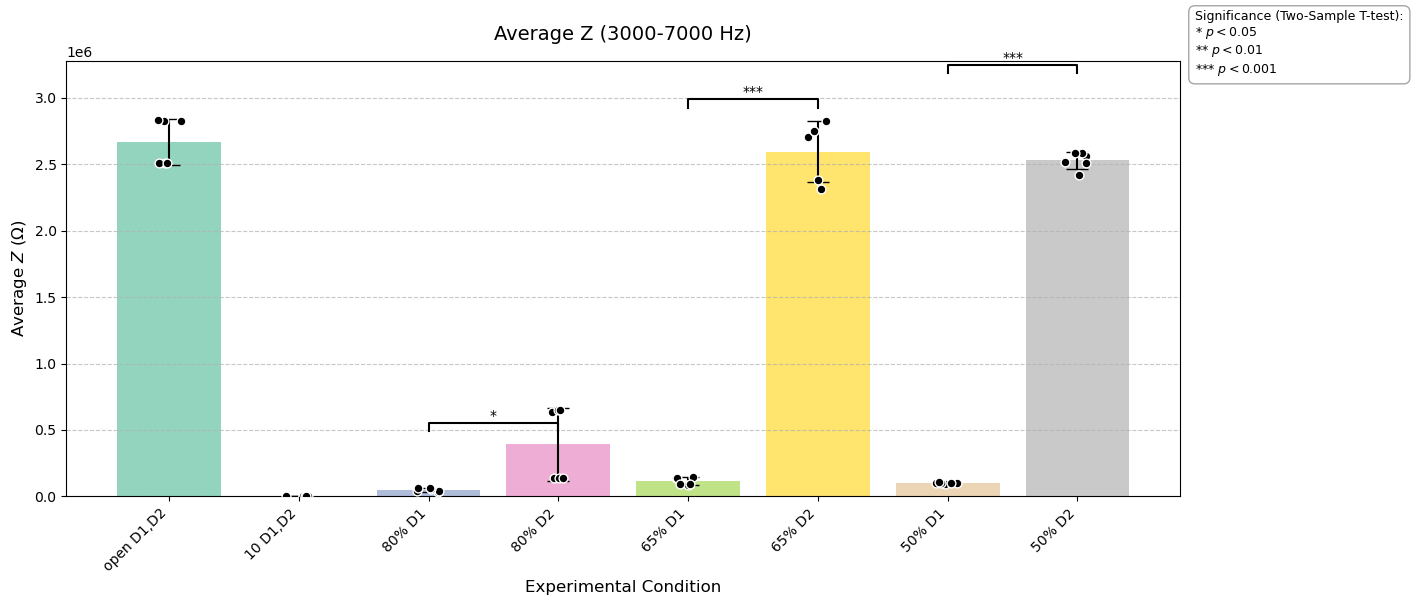

✅ Bar chart with statistical annotations displayed successfully.


In [6]:
# --- NEW HELPER FUNCTION: Stat Annotation Drawer ---

def add_stat_annotation(ax, x1, x2, y_data, data1, data2, h_offset=0.03, bar_height=0.02, fontsize=10):
    """
    Performs an independent two-sample t-test and adds a significance bar 
    and asterisk notation between two groups (x1 and x2).

    Args:
        ax: Matplotlib axes object.
        x1 (int): X position of the first bar.
        x2 (int): X position of the second bar.
        y_data (list): List of mean Y values (used to find max bar height).
        data1 (list): Raw data points for the first group.
        data2 (list): Raw data points for the second group.
        h_offset (float): Vertical offset from the bar top (relative to y-axis range).
        bar_height (float): Height of the annotation line (relative to y-axis range).
        fontsize (int): Font size for the asterisk.
    """
    if not data1 or not data2:
        return # Skip if either group is empty

    # 1. Perform T-test (Assuming independent two-sample test)
    # Filter out potential non-numeric data before the test
    clean_data1 = [d for d in data1 if isinstance(d, (int, float))]
    clean_data2 = [d for d in data2 if isinstance(d, (int, float))]

    if len(clean_data1) < 2 or len(clean_data2) < 2:
        # Not enough samples for a valid t-test
        p_value = 1.0 
    else:
        # T-test for independent samples (assuming unequal variances by default)
        t_stat, p_value = stats.ttest_ind(clean_data1, clean_data2, equal_var=False)

    # 2. Determine Significance Label (Star notation)
    if p_value < 0.001:
        star_label = '***'
    elif p_value < 0.01:
        star_label = '**'
    elif p_value < 0.05:
        star_label = '*'
    else:
        star_label = 'ns' # Not significant

    # 3. Draw Annotation ONLY if P-value is significant (or if you want to show 'ns')
    if star_label != 'ns':
        # Calculate annotation height
        y_max = max(y_data[x1], y_data[x2])
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        
        # Determine the y position for the bar (start above the highest bar/error bar)
        y_start = y_max + y_range * h_offset
        y_bar = y_start + y_range * bar_height
        
        # Draw the significance bar
        ax.plot([x1, x1, x2, x2], [y_start, y_bar, y_bar, y_start], 
                lw=1.5, c='k', clip_on=False) 
        
        # Place the significance label (stars)
        ax.text((x1 + x2) * 0.5, y_bar, star_label, ha='center', va='bottom', 
                fontsize=fontsize, color='k')


# --- MAIN PLOTTING FUNCTION ---

def plot_z_avg_bar_chart(excel_file_path: str):
    """
    Reads the summary Excel file, calculates the average Z_avg and standard 
    deviation for eight specific experimental groupings, and generates a 
    bar chart with error bars, individual data points, and significance 
    annotations.

    Args:
        excel_file_path (str): The path to the "aw_D_EIS_analysis.xlsx" file.
    """
    if not os.path.exists(excel_file_path):
        print(f"\n❌ Error: File not found at path: {excel_file_path}")
        print("Please ensure the previous function successfully created the summary Excel file.")
        return

    print("\n--- Starting Bar Chart Generation ---")

    try:
        df = pd.read_excel(excel_file_path)
        df['Z_avg'] = pd.to_numeric(df['Z_avg'], errors='coerce')
        df.dropna(subset=['Z_avg'], inplace=True)
        
        if df.empty:
            print("⚠️ The DataFrame is empty after cleaning. Cannot generate plot.")
            return

    except Exception as e:
        print(f"❌ Error reading or processing Excel data with pandas: {e}")
        return

    # 1. Define the 8 specific groups and their filtering logic
    plot_groups: List[Tuple[str, callable]] = [
        # Indices 0-1
        ("open D1,D2", lambda row: row['experiment'] == 'open'),
        ("10 D1,D2", lambda row: row['experiment'] == '10'),
        
        # Indices 2-3 (First comparison pair)
        ("80% D1", lambda row: row['experiment'] == '80%' and row['day'] == 'D1'),
        ("80% D2", lambda row: row['experiment'] == '80%' and row['day'] == 'D2'),
        
        # Indices 4-5 (Second comparison pair)
        ("65% D1", lambda row: row['experiment'] == '65%' and row['day'] == 'D1'),
        ("65% D2", lambda row: row['experiment'] == '65%' and row['day'] == 'D2'),
        
        # Indices 6-7 (Third comparison pair)
        ("50% D1", lambda row: row['experiment'] == '50%' and row['day'] == 'D1'),
        ("50% D2", lambda row: row['experiment'] == '50%' and row['day'] == 'D2'),
    ]

    # Storage for plot data
    x_labels = []
    y_means = []
    y_errors = []
    scatter_data = [] # Raw points for statistical testing and strip plotting

    # 2. Calculate stats for each group
    for label, filter_func in plot_groups:
        group_data = df[df.apply(filter_func, axis=1)]['Z_avg']
        
        if not group_data.empty:
            mean = group_data.mean()
            std = group_data.std()
            
            x_labels.append(label)
            y_means.append(mean)
            y_errors.append(std if not pd.isna(std) else 0) 
            scatter_data.append(group_data.tolist())
        else:
            print(f"  Note: No data found for group: {label}")
            # If a group has no data, we add placeholders to maintain index consistency
            x_labels.append(label)
            y_means.append(0)
            y_errors.append(0)
            scatter_data.append([])


    # 3. Create the Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    x_positions = np.arange(len(x_labels))

    # Bar Plot: Main average values
    bar_colors = plt.cm.get_cmap('Set2', len(x_labels))
    ax.bar(
        x_positions, 
        y_means, 
        yerr=y_errors, 
        capsize=8, 
        color=bar_colors(x_positions), 
        alpha=0.7,
        label='Average Z'
    )

    # Scatter Plot: Individual data points
    for i, points in enumerate(scatter_data):
        if points:
            jitter = np.random.uniform(-0.1, 0.1, size=len(points))
            x_scatter = x_positions[i] + jitter
            ax.scatter(
                x_scatter, 
                points, 
                color='black', 
                s=40, 
                zorder=3,
                edgecolors='white',
                linewidths=1
            )

    # 4. Add Statistical Significance Annotations
    
    # We need the max height of the error bars for proper positioning
    # Calculate the max height of the highest error bar to set the initial annotation y-level
    y_max_initial = max(np.array(y_means) + np.array(y_errors) * 1.05) if y_means else 0
    
    # Manually adjust the initial y-limit to create space for annotations
    y_max_plot = y_max_initial * 1.15
    ax.set_ylim(bottom=0, top=y_max_plot) 

    # Comparison 1: "80% D1" (Index 2) vs "80% D2" (Index 3)
    add_stat_annotation(ax, 2, 3, y_means, scatter_data[2], scatter_data[3])
    
    # Comparison 2: "65% D1" (Index 4) vs "65% D2" (Index 5)
    add_stat_annotation(ax, 4, 5, y_means, scatter_data[4], scatter_data[5], h_offset=0.1) # Add more offset if needed

    # Comparison 3: "50% D1" (Index 6) vs "50% D2" (Index 7)
    add_stat_annotation(ax, 6, 7, y_means, scatter_data[6], scatter_data[7], h_offset=0.2) # Add even more offset

    # 5. Final Plot Styling and Legend
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel(r'Average $Z$ ($\Omega$)', fontsize=12) 
    ax.set_xlabel('Experimental Condition', fontsize=12)
    ax.set_title('Average Z (3000-7000 Hz)', fontsize=14, pad=15)
    ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

    # Add the significance legend box
    legend_text = (
        r'Significance (Two-Sample T-test):' + '\n'
        r'* $p < 0.05$' + '\n'
        r'** $p < 0.01$' + '\n'
        r'*** $p < 0.001$'
    )
    
    # Make room on the right for the legend
    plt.subplots_adjust(right=0.78)  # Adjust this fraction as needed
    
    # Add text box to the right outside area
    fig.text(1, 1, legend_text,
             fontsize=9,
             verticalalignment='top',
             horizontalalignment='left',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7, ec="gray"))
    
    plt.tight_layout()

    # Save the figure before showing it
    output_path = "Zavg__plot.png"  # or .pdf, .svg, etc.
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to {output_path}")
    plt.show()
    print("✅ Bar chart with statistical annotations displayed successfully.")

# Call the function to generate and display the plot
plot_z_avg_bar_chart(summary_excel_path)

Figure saved to Zavg_differences_plot.png


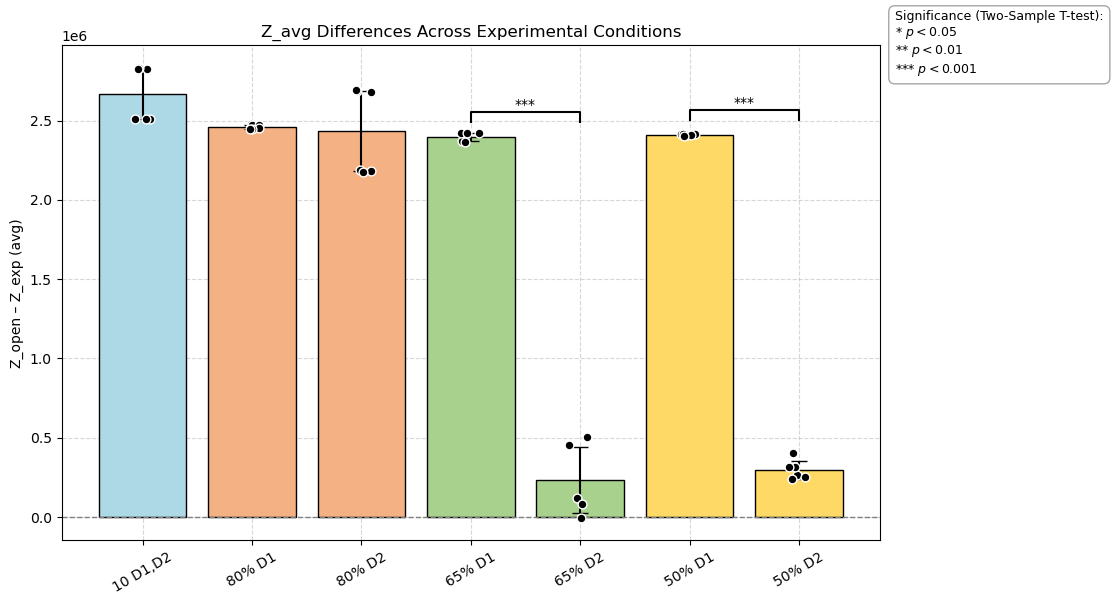

✅ Bar chart with statistical annotations displayed successfully.


In [7]:
def plot_zavg_differences_all(summary_excel_path):
    # Load and clean
    df = pd.read_excel(summary_excel_path)
    df['Z_avg'] = pd.to_numeric(df['Z_avg'], errors='coerce')
    df['T'] = df['T'].fillna('NaN')
    df_indexed = df.set_index(['experiment', 'day', 'T', 'M'])

    def get_zavg(exp, day, T, M):
        key = (exp, day, T if T is not None else 'NaN', M)
        return df_indexed.loc[key, 'Z_avg'] if key in df_indexed.index else None

    # Define all groups
    groups = [
        ("10 D1,D2",  [('10', 'D1', None), ('10', 'D2', None)]),
        ("80% D1",    [('80%', 'D1', 'T1'), ('80%', 'D1', 'T2')]),
        ("80% D2",    [('80%', 'D2', 'T1'), ('80%', 'D2', 'T2')]),
        ("65% D1",    [('65%', 'D1', 'T1'), ('65%', 'D1', 'T2')]),
        ("65% D2",    [('65%', 'D2', 'T1'), ('65%', 'D2', 'T2')]),
        ("50% D1",    [('50%', 'D1', 'T1'), ('50%', 'D1', 'T2')]),
        ("50% D2",    [('50%', 'D2', 'T1'), ('50%', 'D2', 'T2')])
    ]

    # Compute differences
    group_diffs = {}
    for label, exps in groups:
        diffs = []
        for exp, day, T in exps:
            for M in ['M1', 'M2', 'M3']:
                z_open = get_zavg('open', day, None, M)
                z_exp = get_zavg(exp, day, T, M)
                if pd.notna(z_open) and pd.notna(z_exp):
                    diffs.append(z_open - z_exp)
        group_diffs[label] = diffs

    # Prepare data for plotting
    x_positions = np.arange(len(groups))
    means = [np.mean(group_diffs[g]) if group_diffs[g] else np.nan for g, _ in groups]
    stds = [np.std(group_diffs[g]) if group_diffs[g] else np.nan for g, _ in groups]

    # Plot setup
    fig, ax = plt.subplots(figsize=(9, 6))
    bar_colors = ['lightblue'] + ['#f4b183', '#f4b183'] + ['#a9d18e', '#a9d18e'] + ['#ffd966', '#ffd966']

    # Draw bars and scatter points
    for i, (label, _) in enumerate(groups):
        diffs = group_diffs[label]
        ax.bar(i, means[i], yerr=stds[i], capsize=6, color=bar_colors[i], edgecolor='k', zorder=2)
        if diffs:
            jitter = np.random.uniform(-0.1, 0.1, len(diffs))
            ax.scatter(np.full(len(diffs), i) + jitter, diffs, color='k', s=40, zorder=3,edgecolors='white',)

    # Add significance comparisons
    add_stat_annotation(ax, 1, 2, means, group_diffs["80% D1"], group_diffs["80% D2"])
    add_stat_annotation(ax, 3, 4, means, group_diffs["65% D1"], group_diffs["65% D2"])
    add_stat_annotation(ax, 5, 6, means, group_diffs["50% D1"], group_diffs["50% D2"])

    # Final styling
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([g[0] for g in groups], rotation=30)
    ax.set_ylabel("Z_open – Z_exp (avg)")
    ax.set_title("Z_avg Differences Across Experimental Conditions")
    ax.grid(True, linestyle='--', alpha=0.5)

    # Add the significance legend box
    legend_text = (
        r'Significance (Two-Sample T-test):' + '\n'
        r'* $p < 0.05$' + '\n'
        r'** $p < 0.01$' + '\n'
        r'*** $p < 0.001$'
    )
    
    # Make room on the right for the legend
    plt.subplots_adjust(right=0.78)  # Adjust this fraction as needed
    
    # Add text box to the right outside area
    fig.text(1, 1, legend_text,
             fontsize=9,
             verticalalignment='top',
             horizontalalignment='left',
             bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7, ec="gray"))

    
    plt.tight_layout()

    # Save the figure before showing it
    output_path = "Zavg_differences_plot.png"  # or .pdf, .svg, etc.
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to {output_path}")
    plt.show()

    print("✅ Bar chart with statistical annotations displayed successfully.")

plot_zavg_differences_all(summary_excel_path)